<a href="https://www.kaggle.com/code/anik234/rice-leaf-disease-using-vit?scriptVersionId=238039335" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# ====================================================
# 1. Imports
# ====================================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from time import perf_counter
import json
import pandas as pd

In [2]:
# 2. Configurations
# ====================================================
TRAIN_DIR = "/kaggle/input/rice-leaf-disease-data1/Leaf_Disease_Dataset/train"
VAL_DIR = "/kaggle/input/rice-leaf-disease-data1/Leaf_Disease_Dataset/validation"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 9
LEARNING_RATE = 1e-4
EPOCHS = 100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
# ====================================================
# 3. Transforms and Dataset
# ====================================================
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train classes:", train_dataset.classes)
print("Validation samples:", len(val_dataset))

Train classes: ['Healthy', 'Mild_Bacterial_blight', 'Mild_Blast', 'Mild_Brownspot', 'Mild_Tungro', 'Severe_Bacterial_blight', 'Severe_Blast', 'Severe_Brownspot', 'Severe_Tungro']
Validation samples: 180


In [4]:
# ====================================================
# 4. ViT Model Definition
# ====================================================
class ViTModel(nn.Module):
    def __init__(self, num_classes):
        super(ViTModel, self).__init__()
        self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        self.vit.heads = nn.Linear(self.vit.hidden_dim, num_classes)

    def forward(self, x):
        return self.vit(x)

model = ViTModel(NUM_CLASSES).to(device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:03<00:00, 88.2MB/s]


In [5]:
# ====================================================
# 5. Loss & Optimizer
# ====================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [6]:
# ====================================================
# 6. Evaluation Function
# ====================================================
def evaluate(model, dataloader):
    model.eval()
    correct = total = 0
    predictions = []
    labels_list = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            predictions.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())
    accuracy = correct / total
    return accuracy, predictions, labels_list

In [7]:
# ====================================================
# 7. Training Loop
# ====================================================
train_scores = []
val_scores = []
for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    model.train()
    epoch_loss = 0
    correct = total = 0
    start = perf_counter()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    val_acc, _, _ = evaluate(model, val_loader)
    
    train_scores.append(train_acc)
    val_scores.append(val_acc)

    end = perf_counter()
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Time: {end - start:.2f}s")


Epoch [1/100]
Train Loss: 42.3109 | Train Acc: 0.8316 | Val Acc: 0.9944 | Time: 120.12s

Epoch [2/100]
Train Loss: 15.6089 | Train Acc: 0.9363 | Val Acc: 0.9667 | Time: 91.74s

Epoch [3/100]
Train Loss: 12.1758 | Train Acc: 0.9466 | Val Acc: 1.0000 | Time: 92.26s

Epoch [4/100]
Train Loss: 12.0362 | Train Acc: 0.9473 | Val Acc: 0.9722 | Time: 92.48s

Epoch [5/100]
Train Loss: 11.4412 | Train Acc: 0.9490 | Val Acc: 1.0000 | Time: 92.81s

Epoch [6/100]
Train Loss: 9.4415 | Train Acc: 0.9593 | Val Acc: 0.9833 | Time: 92.57s

Epoch [7/100]
Train Loss: 8.8956 | Train Acc: 0.9590 | Val Acc: 0.9944 | Time: 92.62s

Epoch [8/100]
Train Loss: 6.7423 | Train Acc: 0.9660 | Val Acc: 0.9500 | Time: 92.87s

Epoch [9/100]
Train Loss: 6.3361 | Train Acc: 0.9650 | Val Acc: 0.9944 | Time: 93.03s

Epoch [10/100]
Train Loss: 5.0096 | Train Acc: 0.9682 | Val Acc: 1.0000 | Time: 92.77s

Epoch [11/100]
Train Loss: 5.8683 | Train Acc: 0.9650 | Val Acc: 0.9556 | Time: 92.71s

Epoch [12/100]
Train Loss: 10.5663

In [8]:
# ====================================================
# 8. Save Model & Assets
# ====================================================
# Save state dict
torch.save(model.state_dict(), "/kaggle/working/vit_rice_leaf.pt")
print("Saved model weights to /kaggle/working/vit_rice_leaf.pt")

# Save full model
torch.save(model, "/kaggle/working/vit_rice_leaf_full_model.pt")
print("Saved full model to /kaggle/working/vit_rice_leaf_full_model.pt")

# Save class label map
label_map = {i: cls_name for i, cls_name in enumerate(train_dataset.classes)}
with open("/kaggle/working/label_map.json", "w") as f:
    json.dump(label_map, f)
print("Saved label map to /kaggle/working/label_map.json")

Saved model weights to /kaggle/working/vit_rice_leaf.pt
Saved full model to /kaggle/working/vit_rice_leaf_full_model.pt
Saved label map to /kaggle/working/label_map.json


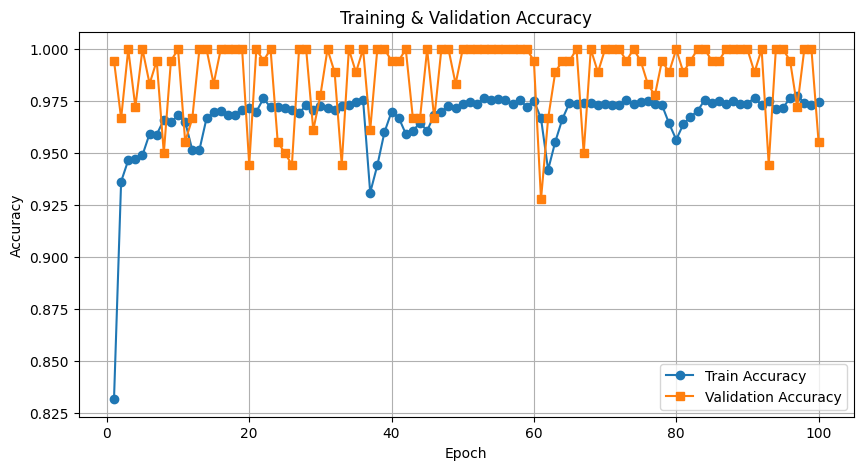

Saved training curve to /kaggle/working/loss_curve.png


In [9]:
# Save accuracy plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), train_scores, marker='o', label='Train Accuracy')
plt.plot(range(1, EPOCHS+1), val_scores, marker='s', label='Validation Accuracy')
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("/kaggle/working/loss_curve.png")
plt.show()
print("Saved training curve to /kaggle/working/loss_curve.png")

In [10]:
# Save predictions to CSV
_, predictions, labels = evaluate(model, val_loader)
pred_df = pd.DataFrame({
    "True Label": [label_map[i] for i in labels],
    "Predicted Label": [label_map[i] for i in predictions]
})
pred_df.to_csv("/kaggle/working/predictions.csv", index=False)
print("Saved predictions to /kaggle/working/predictions.csv")

Saved predictions to /kaggle/working/predictions.csv


Saved prediction image to /kaggle/working/prediction_examples.png


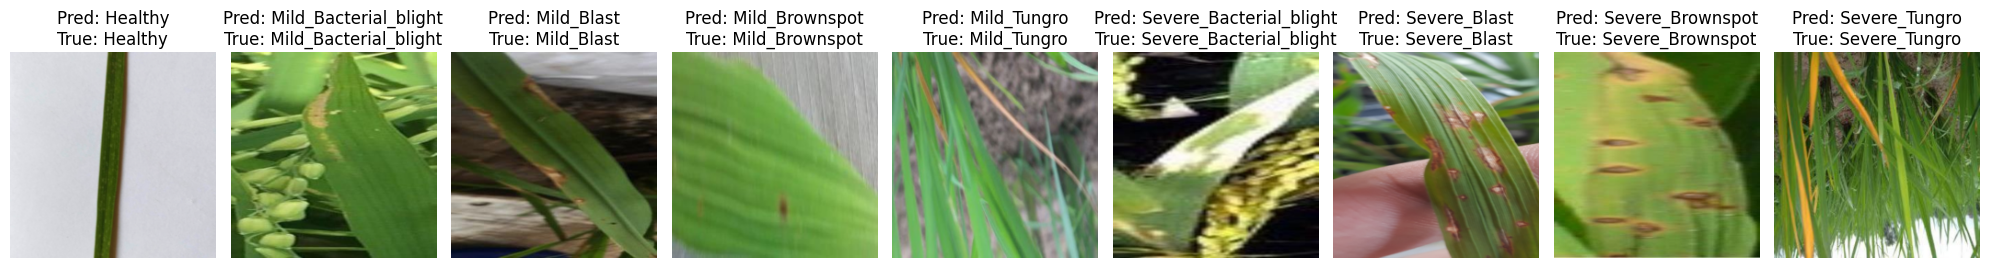

In [11]:
# ====================================================
# 9. Prediction Visualization (One Image Per Class)
# ====================================================
def show_predictions_per_class(model, dataloader, class_names, save_path=None):
    model.eval()
    shown_classes = set()
    plt.figure(figsize=(20, 8))
    idx = 1

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            for i in range(images.size(0)):
                true_label = labels[i].item()
                if true_label not in shown_classes:
                    img = images[i].cpu().permute(1, 2, 0) * 0.5 + 0.5
                    plt.subplot(1, len(class_names), idx)
                    plt.imshow(img)
                    plt.title(f"Pred: {class_names[preds[i]]}\nTrue: {class_names[true_label]}")
                    plt.axis('off')
                    shown_classes.add(true_label)
                    idx += 1
                if len(shown_classes) == len(class_names):
                    break
            if len(shown_classes) == len(class_names):
                break

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f"Saved prediction image to {save_path}")
    plt.show()

# Call updated visualization
show_predictions_per_class(model, val_loader, train_dataset.classes, save_path="/kaggle/working/prediction_examples.png")